# HAM10000 Exploratory Data Analysis

This notebook analyzes the validated HAM10000 dataset before data splitting and
model development.

## Objectives

- verify the generated dataset-audit reports;
- quantify image-level and lesion-level class imbalance;
- examine repeated images per lesion;
- investigate class distribution across acquisition sources;
- inspect demographic and diagnostic metadata;
- define requirements for leakage-safe splitting.

The notebook consumes reproducible audit outputs and does not modify raw data.

In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    
    
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "ham10000"
IMAGE_ROOT = DATA_ROOT / "images"
REPORT_ROOT = PROJECT_ROOT / "reports" / "ham10000_audit"

# ------------------------------------
#print("Project root:", PROJECT_ROOT)
#print("Image root:", IMAGE_ROOT)
#print("Report root:", REPORT_ROOT)

In [3]:
with (REPORT_ROOT / "audit_summary.json").open(encoding="utf-8") as file:
    audit_report = json.load(file)
    
    
inventory = pd.read_csv(REPORT_ROOT / "image_inventory.csv")
class_summary = pd.read_csv(REPORT_ROOT / "class_summary.csv")
source_summary = pd.read_csv(REPORT_ROOT / "source_summary.csv")
lesion_summary = pd.read_csv(REPORT_ROOT / "lesion_summary.csv")


print("Inventory:", inventory.shape)
print("Classes:", class_summary.shape)
print("Sources:", source_summary.shape)
print("Lesions:", lesion_summary.shape)

Inventory: (10015, 18)
Classes: (7, 3)
Sources: (4, 4)
Lesions: (7470, 6)


In [4]:
inventory

,image_id,relative_path,extension,readable,width,height,aspect_ratio,pixel_count,mode,error,has_metadata,lesion_id,class_name,dx_type,age,sex,localization,source
0,ISIC_0024306,images/ISIC_0024306.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0000550,nv,follow_up,45.00,male,trunk,vidir_molemax
1,ISIC_0024307,images/ISIC_0024307.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0003577,nv,follow_up,50.00,male,lower extremity,vidir_molemax
2,ISIC_0024308,images/ISIC_0024308.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0001477,nv,follow_up,55.00,female,trunk,vidir_molemax
3,ISIC_0024309,images/ISIC_0024309.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0000484,nv,follow_up,40.00,male,trunk,vidir_molemax
4,ISIC_0024310,images/ISIC_0024310.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0003350,mel,histo,60.00,male,chest,vidir_modern
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10010,ISIC_0034316,images/ISIC_0034316.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0004304,mel,histo,85.00,male,upper extremity,vidir_modern
10011,ISIC_0034317,images/ISIC_0034317.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0006376,mel,histo,70.00,female,lower extremity,vidir_modern
10012,ISIC_0034318,images/ISIC_0034318.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0000344,bkl,histo,55.00,male,trunk,vidir_modern
10013,ISIC_0034319,images/ISIC_0034319.jpg,.jpg,True,600,450,1.33,270000,RGB,NaN,True,HAM_0000747,nv,histo,30.00,male,trunk,vidir_modern


In [5]:
overview = pd.DataFrame(
    {
        "metric": [
            "Images",
            "Unique lesions",
            "Diagnosis classes",
            "Data sources",
            "Readable images",
            "Images without metadata",
            "Missing ages",
            "Image width",
            "Image height",
        ],
        "value": [
            len(inventory),
            inventory["lesion_id"].nunique(),
            inventory["class_name"].nunique(),
            inventory["source"].nunique(),
            int(inventory["readable"].sum()),
            int((~inventory["has_metadata"]).sum()),
            int(inventory["age"].isna().sum()),
            int(inventory["width"].median()),
            int(inventory["height"].median()),
        ],
    }
)

overview

,metric,value
0,Images,10015
1,Unique lesions,7470
2,Diagnosis classes,7
3,Data sources,4
4,Readable images,10015
5,Images without metadata,0
6,Missing ages,57
7,Image width,600
8,Image height,450


In [6]:
class_analysis = class_summary.copy()

class_analysis["image_percentage"] = (
    100 * class_analysis["image_count"] / class_analysis["image_count"].sum()
)

class_analysis["lesion_percentage"] = (
    100
    * class_analysis["lesion_count"]
    / class_analysis["lesion_count"].sum()
)

class_analysis["images_per_lesion"] = (
    class_analysis["image_count"]
    / class_analysis["lesion_count"]
)

class_analysis = class_analysis.sort_values(
    "image_count",
    ascending=False,
).reset_index(drop=True)

class_analysis.round(2)

,class_name,image_count,lesion_count,image_percentage,lesion_percentage,images_per_lesion
0,nv,6705,5403,66.95,72.33,1.24
1,mel,1113,614,11.11,8.22,1.81
2,bkl,1099,727,10.97,9.73,1.51
3,bcc,514,327,5.13,4.38,1.57
4,akiec,327,228,3.27,3.05,1.43
5,vasc,142,98,1.42,1.31,1.45
6,df,115,73,1.15,0.98,1.58


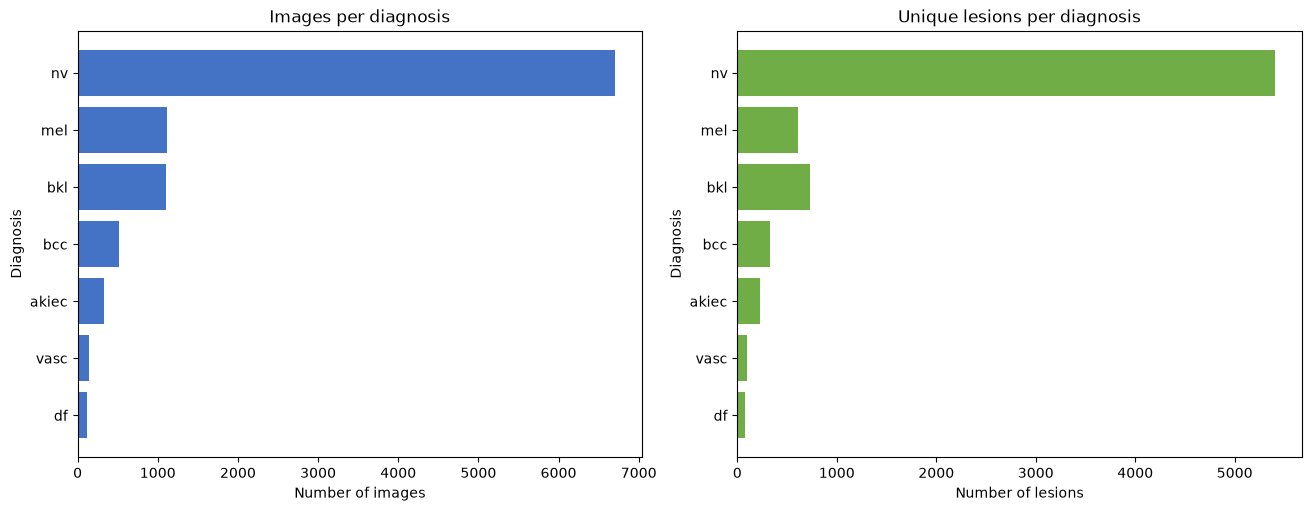

In [7]:
plot_data = class_analysis.sort_values(
    "image_count",
    ascending=True,
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True,
)

axes[0].barh(
    plot_data["class_name"],
    plot_data["image_count"],
    color="#4472C4",
)
axes[0].set_title("Images per diagnosis")
axes[0].set_xlabel("Number of images")
axes[0].set_ylabel("Diagnosis")

axes[1].barh(
    plot_data["class_name"],
    plot_data["lesion_count"],
    color="#70AD47",
)
axes[1].set_title("Unique lesions per diagnosis")
axes[1].set_xlabel("Number of lesions")
axes[1].set_ylabel("Diagnosis")

plt.show()

In [8]:
images_per_lesion = (
    lesion_summary["image_count"]
    .value_counts()
    .sort_index()
    .rename_axis("images_per_lesion")
    .reset_index(name="lesion_count")
)

images_per_lesion

,images_per_lesion,lesion_count
0,1,5514
1,2,1423
2,3,490
3,4,34
4,5,5
5,6,4


In [ ]:
images_per_lesion = (
    lesion_summary["image_count"]
    .value_counts()
    .sort_index()
    .rename_axis("images_per_lesion")
    .reset_index(name="lesion_count")
)

images_per_lesion

In [9]:
majority = class_analysis.iloc[0]
minority = class_analysis.iloc[-1]

imbalance_ratio = (
    majority["image_count"] / minority["image_count"]
)

print(
    f"Majority class: {majority['class_name']} "
    f"({majority['image_count']:,} images)"
)

print(
    f"Minority class: {minority['class_name']} "
    f"({minority['image_count']:,} images)"
)

print(f"Image-level imbalance ratio: {imbalance_ratio:.1f}:1")

Majority class: nv (6,705 images)
Minority class: df (115 images)
Image-level imbalance ratio: 58.3:1


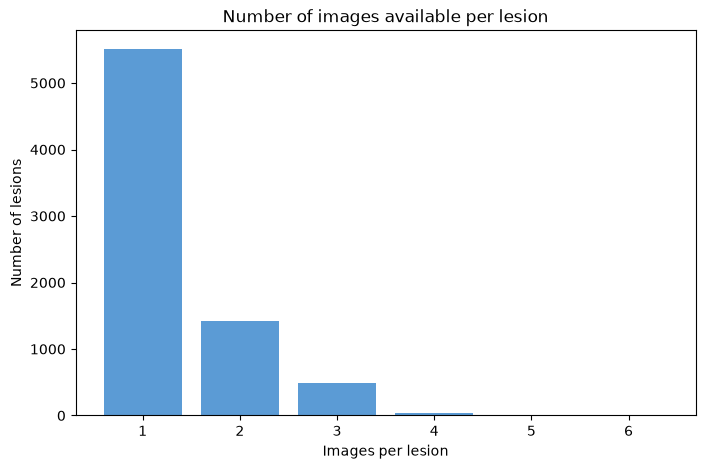

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    images_per_lesion["images_per_lesion"].astype(str),
    images_per_lesion["lesion_count"],
    color="#5B9BD5",
)

ax.set_title("Number of images available per lesion")
ax.set_xlabel("Images per lesion")
ax.set_ylabel("Number of lesions")

plt.show()

In [12]:
multi_image_lesions = lesion_summary[
    lesion_summary["image_count"] > 1
]

print(
    "Multi-image lesions:",
    f"{len(multi_image_lesions):,}",
)

print(
    "Percentage of lesions:",
    f"{100 * len(multi_image_lesions) / len(lesion_summary):.2f}%",
)

print(
    "Images belonging to multi-image lesions:",
    f"{multi_image_lesions['image_count'].sum():,}",
)

Multi-image lesions: 1,956
Percentage of lesions: 26.18%
Images belonging to multi-image lesions: 4,501


### Finding

The dataset is severely imbalanced. Melanocytic nevi (`nv`) account for roughly
67% of all images, while dermatofibroma (`df`) represents approximately 1.15%.

The baseline evaluation should therefore prioritize macro F1, balanced accuracy,
per-class recall, and the confusion matrix rather than accuracy alone.

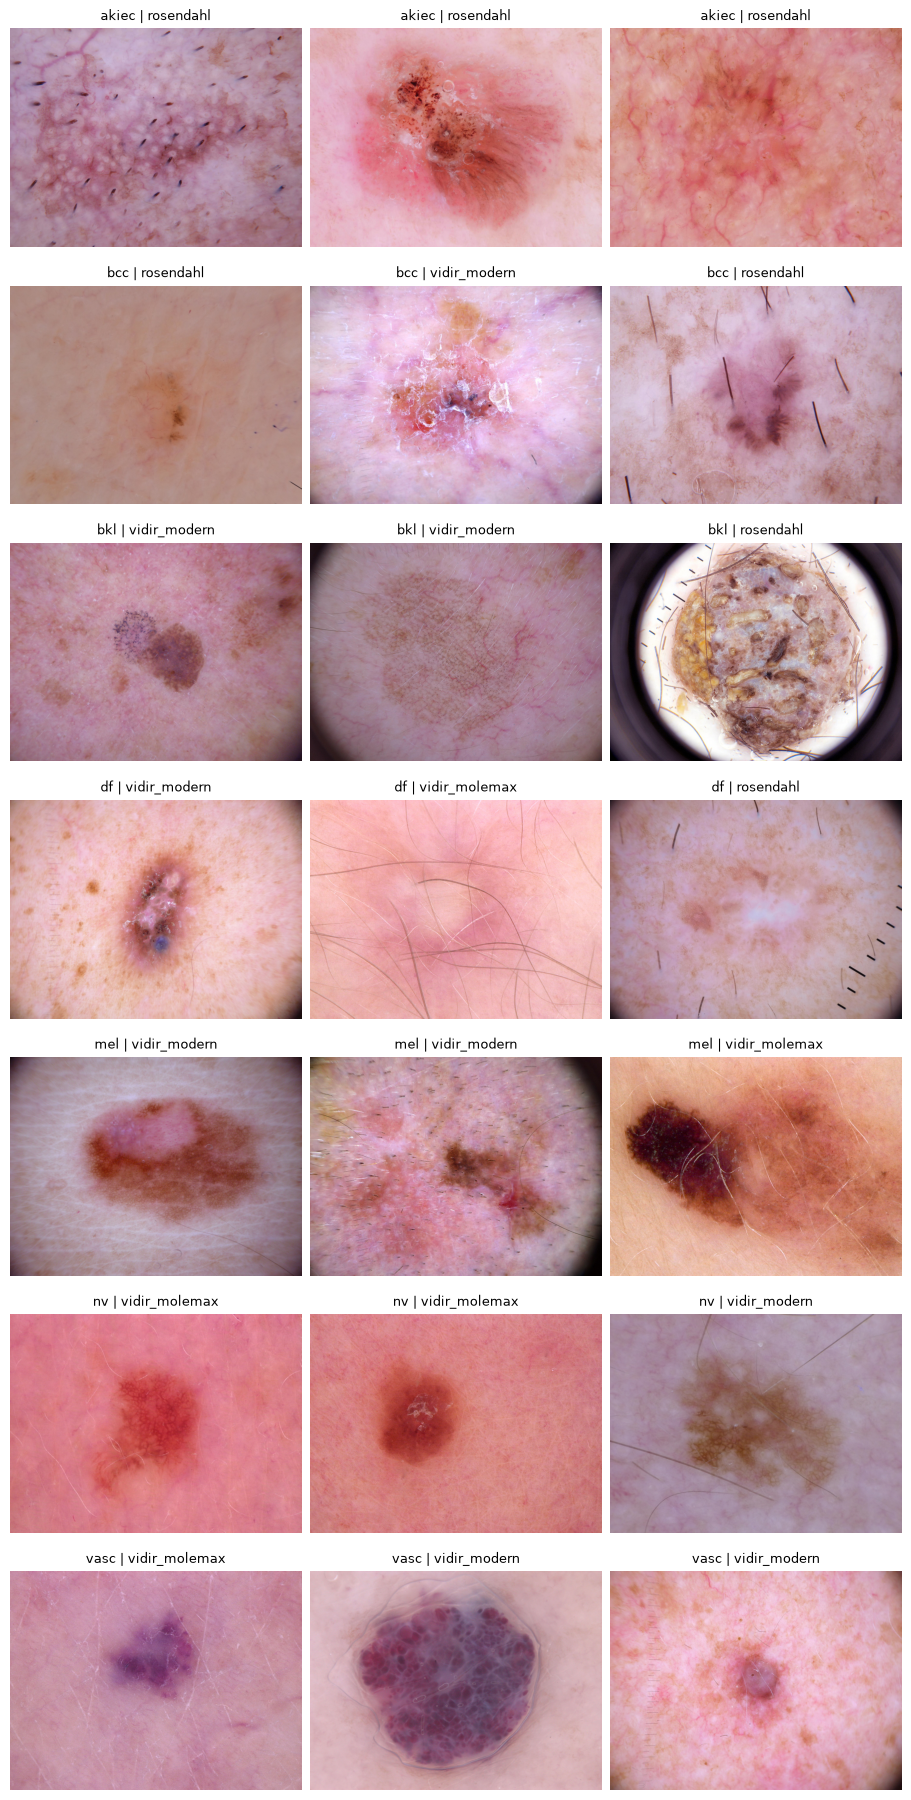

In [10]:
class_order = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

samples = (
    inventory.groupby("class_name", group_keys=False)
    .sample(n=3, random_state=42)
)

fig, axes = plt.subplots(
    len(class_order),
    3,
    figsize=(9, 18),
    constrained_layout=True,
)

for row_index, class_name in enumerate(class_order):
    class_samples = samples[
        samples["class_name"] == class_name
    ].reset_index(drop=True)

    for column_index, sample in class_samples.iterrows():
        image_path = DATA_ROOT / sample["relative_path"]

        with Image.open(image_path) as image:
            axes[row_index, column_index].imshow(image)

        axes[row_index, column_index].set_title(
            f"{class_name} | {sample['source']}",
            fontsize=9,
        )
        axes[row_index, column_index].axis("off")

plt.show()

In [13]:
source_analysis = source_summary.copy()

source_analysis["image_percentage"] = (
    100
    * source_analysis["image_count"]
    / source_analysis["image_count"].sum()
)

source_analysis["images_per_lesion"] = (
    source_analysis["image_count"]
    / source_analysis["lesion_count"]
)

source_analysis.round(2)

,source,image_count,lesion_count,class_count,image_percentage,images_per_lesion
0,rosendahl,2259,1552,7,22.56,1.46
1,vidir_modern,3363,1695,7,33.58,1.98
2,vidir_molemax,3954,3954,6,39.48,1.00
3,vienna_dias,439,278,6,4.38,1.58


In [14]:
source_class_counts = pd.crosstab(
    inventory["source"],
    inventory["class_name"],
)

source_class_percentages = pd.crosstab(
    inventory["source"],
    inventory["class_name"],
    normalize="index",
) * 100

source_class_counts

class_name,akiec,bcc,bkl,df,mel,nv,vasc
source,,,,,,,
rosendahl,295,296,490,30,342,803,3
vidir_modern,32,211,475,51,680,1832,82
vidir_molemax,0,2,124,30,24,3720,54
vienna_dias,0,5,10,4,67,350,3


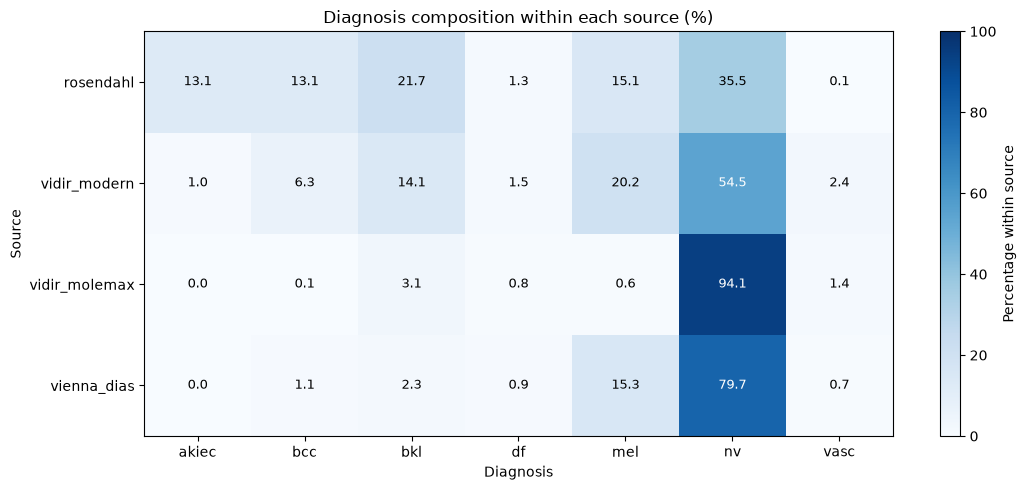

In [16]:
fig, ax = plt.subplots(figsize=(11, 5))

values = source_class_percentages.to_numpy()

image = ax.imshow(
    values,
    cmap="Blues",
    aspect="auto",
    vmin=0,
    vmax=100,
)

ax.set_xticks(range(len(source_class_percentages.columns)))
ax.set_xticklabels(source_class_percentages.columns)

ax.set_yticks(range(len(source_class_percentages.index)))
ax.set_yticklabels(source_class_percentages.index)

ax.set_xlabel("Diagnosis")
ax.set_ylabel("Source")
ax.set_title("Diagnosis composition within each source (%)")

for row in range(values.shape[0]):
    for column in range(values.shape[1]):
        value = values[row, column]
        text_color = "white" if value > 50 else "black"

        ax.text(
            column,
            row,
            f"{value:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
        )

fig.colorbar(image, ax=ax, label="Percentage within source")
plt.tight_layout()
plt.show()

In [17]:
metadata_columns = [
    "lesion_id",
    "class_name",
    "dx_type",
    "age",
    "sex",
    "localization",
    "source",
]

missing_summary = pd.DataFrame(
    {
        "missing_count": inventory[metadata_columns].isna().sum(),
        "missing_percentage": (
            100
            * inventory[metadata_columns].isna().mean()
        ),
    }
)

missing_summary.round(2)

,missing_count,missing_percentage
lesion_id,0,0.00
class_name,0,0.00
dx_type,0,0.00
age,57,0.57
sex,0,0.00
localization,0,0.00
source,0,0.00


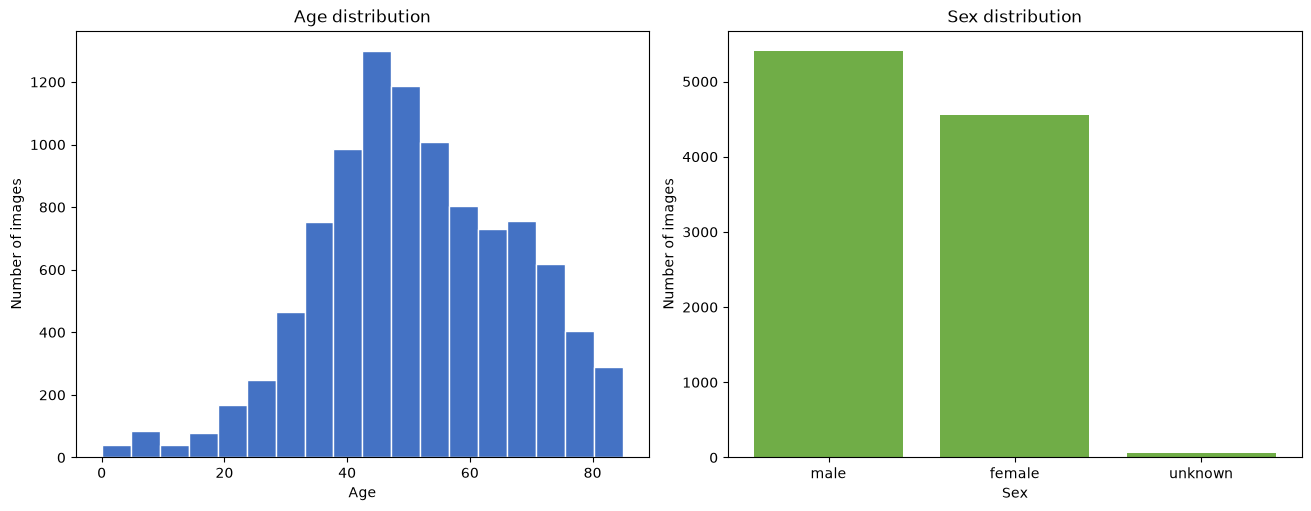

In [19]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    constrained_layout=True,
)

inventory["age"].dropna().plot(
    kind="hist",
    bins=18,
    color="#4472C4",
    edgecolor="white",
    ax=axes[0],
)

axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of images")

sex_counts = inventory["sex"].value_counts()
axes[1].bar(
    sex_counts.index,
    sex_counts.values,
    color="#70AD47",
)

axes[1].set_title("Sex distribution")
axes[1].set_xlabel("Sex")
axes[1].set_ylabel("Number of images")

plt.show()

## Conclusions and pre-split requirements

The HAM10000 dataset passed the implemented file and metadata integrity checks:

- all 10,015 images are readable;
- all image IDs match metadata records;
- no duplicate image IDs were detected;
- all seven expected diagnosis classes are present;
- every image has a lesion ID and acquisition source.

The EDA identified three important modeling risks:

1. **Class imbalance:** `nv` accounts for approximately 67% of the images.
2. **Lesion leakage:** 1,956 lesions have more than one image.
3. **Source confounding:** diagnosis distributions differ substantially across
   acquisition sources.

The data-splitting implementation must therefore:

- group images by `lesion_id`;
- approximately preserve class proportions;
- use a fixed random seed;
- ensure no lesion appears in multiple splits;
- report image and lesion counts for every split;
- report class and source distributions across splits;
- verify the generated split manifests automatically.

The first baseline will use all data sources. Source-held-out evaluation will be
implemented later as a domain-shift experiment.